## **EPSILON SWEEP - IMU AND HR**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)

# ================================================
# CONFIG
# ================================================
SUBJECT_IDS    = [101, 102, 103, 104, 105, 106, 107, 108]
FILE_PATTERN   = "subject{}.dat"

HARNET_EPOCHS     = 20
HARNET_BATCH_SIZE = 32
HARNET_LR         = 1e-3
SAMPLING_RATE     = 30
WINDOW_SEC        = 10
STEP_SEC          = 5
WINDOW_SAMPLES    = int(WINDOW_SEC * SAMPLING_RATE)
STEP_SAMPLES      = int(STEP_SEC  * SAMPLING_RATE)
DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MLP_EPOCHS        = 20
MLP_BATCH_SIZE    = 32
FUSION_MLP_EPOCHS = 50
FUSION_MLP_BATCH  = 32

# Conditions to evaluate
EPSILON_VALUES_ALL = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, None]
ALPHA_THRESHOLD = 30.0

# Create output directories
os.makedirs("imu_probs_cache", exist_ok=True)
os.makedirs("hr_probs_cache", exist_ok=True)
os.makedirs("scalers", exist_ok=True)
os.makedirs("results", exist_ok=True)

# ================================================
# Activities
# ================================================
all_activities    = [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24]
activity_to_class = {act: i for i, act in enumerate(all_activities)}
num_classes       = len(all_activities)

class_names = [
    "lying", "sitting", "standing", "walking", "running", "cycling",
    "Nordic walking", "watching TV", "computer work", "car driving",
    "ascending stairs", "descending stairs", "vacuum cleaning", "ironing",
    "folding laundry", "house cleaning", "playing soccer", "rope jumping"
]

# ================================================
# Column setup
# ================================================
base_cols = ["timestamp", "activity_id", "heart_rate"]
imu_cols  = [
    "temp",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x",  "acc6_y",  "acc6_z",
    "gyro_x",  "gyro_y",  "gyro_z",
    "mag_x",   "mag_y",   "mag_z",
    "ori_1",   "ori_2",   "ori_3",   "ori_4"
]
hand_cols  = [f"hand_{c}"  for c in imu_cols]
chest_cols = [f"chest_{c}" for c in imu_cols]
ankle_cols = [f"ankle_{c}" for c in imu_cols]
all_cols   = base_cols + hand_cols + chest_cols + ankle_cols


def load_raw(subject_id):
    path = FILE_PATTERN.format(subject_id)
    df   = pd.read_csv(path, sep=r"\s+", header=None, na_values="NaN")
    if df.shape[1] != 54:
        raise ValueError(f"Subject {subject_id}: expected 54 cols, got {df.shape[1]}")
    df.columns = all_cols
    return df


# ================================================
# Differential Privacy
# ================================================

def identify_salient_points(timestamps, values, alpha=ALPHA_THRESHOLD):
    n = len(timestamps)
    if n < 2:
        return list(range(n))

    derivatives = np.zeros(n)
    for i in range(1, n):
        dt = timestamps[i] - timestamps[i-1]
        derivatives[i] = (values[i] - values[i-1]) / dt if dt > 0 else 0

    list1_idx = [0] + [i for i in range(1, n-1) if derivatives[i] != 0] + [n-1]

    list2_idx = [list1_idx[0]]
    t_start   = timestamps[list1_idx[0]]

    for j in range(1, len(list1_idx) - 1):
        cur_idx  = list1_idx[j]
        next_idx = list1_idx[j+1] if j+1 < len(list1_idx) else None
        t_int    = timestamps[cur_idx] - t_start

        if next_idx is not None:
            d_cur, d_next = derivatives[cur_idx], derivatives[next_idx]
            same_sign = (d_cur > 0 and d_next > 0) or (d_cur < 0 and d_next < 0)
        else:
            same_sign = False

        if same_sign and t_int <= alpha:
            continue
        else:
            list2_idx.append(cur_idx)
            t_start = timestamps[cur_idx]

    list2_idx.append(list1_idx[-1])
    return list2_idx


def adaptive_laplace_noise(values, salient_idx, epsilon):
    salient_vals = values[salient_idx]
    p = len(salient_vals)
    if p == 0:
        return salient_vals.copy()

    x_min, x_max, x_mean = salient_vals.min(), salient_vals.max(), salient_vals.mean()
    delta_s   = x_max - x_min if x_max != x_min else 1.0
    epsilon_i = epsilon / p

    noisy = salient_vals.copy().astype(float)
    for k, val in enumerate(salient_vals):
        y_i = np.clip((val - x_mean) / delta_s, -1, 1)
        r_i = np.clip(
            (np.exp(epsilon_i) - 1) / (2 * np.exp(epsilon_i) + 2) * y_i + 0.5,
            0, 1
        )
        noisy[k] = val + r_i * np.random.laplace(0, delta_s / epsilon_i)
    return noisy


def reconstruct_linear(timestamps, values, salient_idx, noisy_salient):
    return np.interp(timestamps, timestamps[salient_idx], noisy_salient)


def apply_hr_dp(timestamps, hr_values, epsilon,
                window_sec=10.0, step_sec=5.0):
    """Per-window DP on HR signal resampled to 1Hz."""
    valid = ~np.isnan(hr_values)
    if valid.sum() < 2:
        return hr_values.copy()

    t_valid, hr_valid = timestamps[valid], hr_values[valid]
    t_1hz  = np.arange(t_valid[0], t_valid[-1], 1.0)
    hr_1hz = np.interp(t_1hz, t_valid, hr_valid)

    reconstructed_1hz = hr_1hz.copy().astype(float)
    w_start = t_1hz[0]
    while w_start + window_sec <= t_1hz[-1]:
        w_end = w_start + window_sec
        mask  = (t_1hz >= w_start) & (t_1hz < w_end)
        if mask.sum() < 2:
            w_start += step_sec; continue
        t_win, hr_win = t_1hz[mask], hr_1hz[mask]
        local_idx     = np.where(mask)[0]
        sal           = identify_salient_points(t_win, hr_win)
        noisy         = adaptive_laplace_noise(hr_win, sal, epsilon)
        reconstructed_1hz[local_idx] = reconstruct_linear(t_win, hr_win, sal, noisy)
        w_start += step_sec

    result        = hr_values.copy().astype(float)
    result[valid] = np.interp(t_valid, t_1hz, reconstructed_1hz)
    return result


def apply_imu_dp_channel(timestamps, channel_values, epsilon,
                          window_sec=10.0, step_sec=5.0):
    """Per-window DP on a single IMU channel at 30Hz."""
    valid = ~np.isnan(channel_values)
    if valid.sum() < 2:
        return channel_values.copy()

    t_valid, ch_valid = timestamps[valid], channel_values[valid]
    reconstructed     = ch_valid.copy().astype(float)
    w_start           = t_valid[0]

    while w_start + window_sec <= t_valid[-1]:
        w_end     = w_start + window_sec
        mask      = (t_valid >= w_start) & (t_valid < w_end)
        if mask.sum() < 2:
            w_start += step_sec; continue
        t_win, ch_win = t_valid[mask], ch_valid[mask]
        local_idx     = np.where(mask)[0]
        sal           = identify_salient_points(t_win, ch_win)
        noisy         = adaptive_laplace_noise(ch_win, sal, epsilon)
        reconstructed[local_idx] = reconstruct_linear(t_win, ch_win, sal, noisy)
        w_start += step_sec

    result        = channel_values.copy().astype(float)
    result[valid] = reconstructed
    return result


def apply_imu_dp(df_imu, epsilon):
    """Apply DP independently to acc_x, acc_y, acc_z."""
    df_out = df_imu.copy()
    ts = df_imu["timestamp"].dt.total_seconds().values if hasattr(
        df_imu["timestamp"].iloc[0], "total_seconds") else df_imu["timestamp"].values
    for col in ["acc_x", "acc_y", "acc_z"]:
        df_out[col] = apply_imu_dp_channel(ts, df_imu[col].values, epsilon)
    return df_out


# ================================================
# HR feature extraction
# ================================================
LAG_SECONDS = [10, 30, 60, 120]


def extract_hr_features(df, hr_col="heart_rate"):
    hr_df        = df[["timestamp", hr_col, "activity_id"]].dropna()
    timestamps   = hr_df["timestamp"].values
    hr_values    = hr_df[hr_col].values
    activity_ids = hr_df["activity_id"].values.astype(int)

    feature_list, labels_list = [], []
    window_start = 0.0
    window_end   = float(WINDOW_SEC)

    while window_end <= timestamps[-1]:
        idx = (timestamps >= window_start) & (timestamps < window_end)
        if idx.sum() > 0:
            hr_window = hr_values[idx]
            diff_hr   = np.diff(hr_window)
            lags = []
            for lag in LAG_SECONDS:
                lag_idx = (timestamps >= window_start - lag) & (timestamps < window_start)
                lags.append(np.mean(hr_values[lag_idx]) if lag_idx.sum() > 0
                            else np.mean(hr_window))
            feature_list.append([
                np.mean(hr_window), np.std(hr_window),
                np.min(hr_window),  np.max(hr_window),
                np.max(hr_window) - np.min(hr_window),
                (hr_window[-1] - hr_window[0]) / WINDOW_SEC,
                np.sqrt(np.mean(diff_hr**2)) if len(diff_hr) > 0 else 0,
                np.mean(diff_hr)              if len(diff_hr) > 0 else 0,
                np.std(diff_hr)               if len(diff_hr) > 0 else 0,
            ] + lags)
            labels_list.append(np.bincount(activity_ids[idx]).argmax())

        window_start += STEP_SEC
        window_end    = window_start + WINDOW_SEC

    return np.array(feature_list), np.array(labels_list)


def filter_activities(X, y_raw):
    valid = np.isin(y_raw, list(activity_to_class.keys()))
    return X[valid], np.array([activity_to_class[a] for a in y_raw[valid]])


def build_mlp(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(), Dropout(0.4),
        Dense(64,  activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# ================================================
# IMU processing
# ================================================

def preprocess_imu(df, epsilon=None):
    raw = df[["timestamp", "activity_id"]].copy()
    raw["acc_x"] = df["hand_acc16_x"].interpolate(method="linear", limit_direction="both")
    raw["acc_y"] = df["hand_acc16_y"].interpolate(method="linear", limit_direction="both")
    raw["acc_z"] = df["hand_acc16_z"].interpolate(method="linear", limit_direction="both")
    raw = raw.sort_values("timestamp").reset_index(drop=True)
    raw = raw.set_index("timestamp")
    raw.index = pd.to_timedelta(raw.index, unit="s")
    raw = raw.resample("0.0333s").agg({
        "activity_id": lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
        "acc_x": "mean", "acc_y": "mean", "acc_z": "mean",
    }).reset_index()
    if epsilon is not None:
        raw = apply_imu_dp(raw, epsilon)
    return raw


def create_imu_windows(df):
    acc_x, acc_y, acc_z = df["acc_x"].values, df["acc_y"].values, df["acc_z"].values
    acts = df["activity_id"].values
    X_list, y_list = [], []
    for i in range(0, len(df) - WINDOW_SAMPLES, STEP_SAMPLES):
        window = np.array([
            acc_x[i: i + WINDOW_SAMPLES],
            acc_y[i: i + WINDOW_SAMPLES],
            acc_z[i: i + WINDOW_SAMPLES],
        ])
        X_list.append(window)
        y_list.append(acts[i: i + WINDOW_SAMPLES])
    return np.array(X_list), np.array(y_list)


def clean_imu_windows(X, y):
    mask = [(np.sum(w == 0) / len(w)) < 0.5 for w in y]
    return X[mask], y[mask]


def majority_vote(y):
    from scipy import stats
    return stats.mode(y, axis=1).mode.reshape(-1)


def load_imu_subject(subject_id, epsilon=None):
    df       = load_raw(subject_id)
    df_imu   = preprocess_imu(df, epsilon=epsilon)
    X, y_raw = create_imu_windows(df_imu)
    X, y_raw = clean_imu_windows(X, y_raw)
    y_vote   = majority_vote(y_raw)
    mask     = np.isin(y_vote, all_activities)
    X_f      = X[mask]
    y_f      = np.array([activity_to_class[a] for a in y_vote[mask]])
    return X_f, y_f


class CustomScaler:
    def __init__(self):
        self._sc = StandardScaler(); self._fitted = False

    def fit_transform(self, X):
        N, C, T = X.shape
        flat = X.transpose(0, 2, 1).reshape(-1, C)
        scaled = self._sc.fit_transform(flat)
        self._fitted = True
        return scaled.reshape(N, T, C).transpose(0, 2, 1)

    def transform(self, X):
        N, C, T = X.shape
        flat = X.transpose(0, 2, 1).reshape(-1, C)
        return self._sc.transform(flat).reshape(N, T, C).transpose(0, 2, 1)


def build_harnet10(n_classes):
    return torch.hub.load("OxWearables/ssl-wearables", "harnet10",
                          class_num=n_classes, pretrained=True, force_reload=False)


def make_loader(X, y, batch_size, shuffle=False):
    return DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=batch_size, shuffle=shuffle)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += out.argmax(1).eq(y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, 100.0 * correct / total


def get_probs(model, loader, device):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out   = model(X_b.to(device))
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_targets.extend(y_b.numpy())
    return np.array(all_probs), np.array(all_targets)


class EarlyStopping:
    def __init__(self, patience=7):
        self.patience = patience; self.best_loss = float("inf")
        self.counter  = 0; self.best_state = None; self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)


def build_fusion_mlp(input_dim, num_classes):
    """Small MLP that learns to combine HR and IMU softmax vectors."""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# ================================================
# Single LOSO fold — runs everything for one
# test subject under one DP condition
# ================================================

def run_fold(test_sid, train_sids, raw_data_cache, epsilon):
    """
    Run a full fold: train HR MLP + HARNet10, get probs,
    train learned fusion MLP, evaluate.
    epsilon=None → no DP, epsilon=X → DP applied to both HR and IMU.
    Returns dict with acc/f1 for HR-only, IMU-only, and learned fusion.

    SAVES:
    - HR probs (train and test) to hr_probs_cache/
    - IMU probs (train and test) to imu_probs_cache/
    """
    eps_str = "nodp" if epsilon is None else f"eps{epsilon}"
    label = "No DP" if epsilon is None else f"ε={epsilon}"

    print(f"\n{'='*60}")
    print(f"  Running fold: test_subject={test_sid}, {label}")
    print(f"{'='*60}")

    # ---- HR data ----
    print(f"  [1/4] Processing HR data...")
    hr_data = {}
    for sid in train_sids + [test_sid]:
        df = raw_data_cache[sid].copy()
        if epsilon is not None:
            ts       = df["timestamp"].values
            hr_noisy = apply_hr_dp(ts, df["heart_rate"].values, epsilon)
            df["heart_rate_dp"] = hr_noisy
            hr_col = "heart_rate_dp"
        else:
            hr_col = "heart_rate"
        X, y_raw = extract_hr_features(df, hr_col=hr_col)
        X, y     = filter_activities(X, y_raw)
        hr_data[sid] = (X, y)

    X_hr_train = np.concatenate([hr_data[s][0] for s in train_sids])
    y_hr_train = np.concatenate([hr_data[s][1] for s in train_sids])
    X_hr_test, y_hr_test = hr_data[test_sid]

    hr_scaler  = StandardScaler()
    X_hr_train_scaled = hr_scaler.fit_transform(X_hr_train)
    X_hr_test_scaled  = hr_scaler.transform(X_hr_test)

    unique_cls = np.unique(y_hr_train)
    cw         = compute_class_weight('balanced', classes=unique_cls, y=y_hr_train)
    cw_dict    = {int(c): float(w) for c, w in zip(unique_cls, cw)}

    print(f"  [2/4] Training HR MLP...")
    hr_mlp = build_mlp(X_hr_train_scaled.shape[1])
    hr_mlp.fit(X_hr_train_scaled, to_categorical(y_hr_train, num_classes),
               epochs=MLP_EPOCHS, batch_size=MLP_BATCH_SIZE,
               class_weight=cw_dict, verbose=0)

    # Get HR probs and save them
    hr_test_probs = hr_mlp.predict(X_hr_test_scaled, verbose=0)
    hr_acc = accuracy_score(y_hr_test, hr_test_probs.argmax(axis=1))
    hr_f1  = f1_score(y_hr_test, hr_test_probs.argmax(axis=1),
                      average="macro", zero_division=0)

    # Save test HR probs
    hr_test_df = pd.DataFrame(
        hr_test_probs,
        columns=[f"hr_p{i}" for i in range(num_classes)]
    )
    hr_test_df["y_true"] = y_hr_test
    hr_test_df["subject"] = test_sid
    hr_test_path = f"hr_probs_cache/hr_test_sub{test_sid}_{eps_str}.csv"
    hr_test_df.to_csv(hr_test_path, index=False)
    print(f"    ✓ Saved: {hr_test_path}")

    # ---- IMU data ----
    print(f"  [3/4] Processing IMU data and training HARNet10...")
    imu_data = {}
    for sid in train_sids + [test_sid]:
        imu_data[sid] = load_imu_subject(sid, epsilon=epsilon)

    X_imu_train = np.concatenate([imu_data[s][0] for s in train_sids])
    y_imu_train = np.concatenate([imu_data[s][1] for s in train_sids])
    X_imu_test, y_imu_test = imu_data[test_sid]

    imu_scaler  = CustomScaler()
    X_imu_train_scaled = imu_scaler.fit_transform(X_imu_train)
    X_imu_test_scaled  = imu_scaler.transform(X_imu_test)

    train_loader = make_loader(X_imu_train_scaled, y_imu_train, HARNET_BATCH_SIZE, shuffle=True)
    test_loader  = make_loader(X_imu_test_scaled,  y_imu_test,  HARNET_BATCH_SIZE, shuffle=False)

    harnet    = build_harnet10(num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    for name, param in harnet.named_parameters():
        param.requires_grad = name.startswith("classifier")

    optimizer     = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, harnet.parameters()),
        lr=HARNET_LR, weight_decay=0.01)
    scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
    early_stopper = EarlyStopping(patience=7)

    for epoch in range(1, HARNET_EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(harnet, train_loader, optimizer, criterion, DEVICE)
        va_probs, va_true = get_probs(harnet, test_loader, DEVICE)
        va_loss = criterion(torch.tensor(va_probs), torch.tensor(va_true)).item()
        va_acc  = accuracy_score(va_true, va_probs.argmax(axis=1))
        scheduler.step(va_loss)
        early_stopper(va_loss, harnet)
        if epoch % 5 == 0:
            print(f"    Epoch {epoch:02d}  train_acc={tr_acc:.1f}%  val_acc={va_acc:.3f}")
        if early_stopper.stop:
            print("    Early stopping."); break

    early_stopper.restore(harnet)

    # Get IMU test probs
    imu_test_probs, imu_test_true = get_probs(harnet, test_loader, DEVICE)
    imu_acc = accuracy_score(imu_test_true, imu_test_probs.argmax(axis=1))
    imu_f1  = f1_score(imu_test_true, imu_test_probs.argmax(axis=1),
                       average="macro", zero_division=0)

    # Save test IMU probs
    imu_test_df = pd.DataFrame(
        imu_test_probs,
        columns=[f"imu_p{i}" for i in range(num_classes)]
    )
    imu_test_df["y_true"]  = imu_test_true
    imu_test_df["subject"] = test_sid
    imu_test_path = f"imu_probs_cache/imu_test_sub{test_sid}_{eps_str}.csv"
    imu_test_df.to_csv(imu_test_path, index=False)
    print(f"    ✓ Saved: {imu_test_path}")

    # ---- Save train probs per subject for later fusion experiments ----
    print(f"  [4/4] Saving train probs and running fusion...")

    for sid in train_sids:
        # HR train probs for this subject
        X_hr_sid_scaled = hr_scaler.transform(hr_data[sid][0])
        hr_p_sid = hr_mlp.predict(X_hr_sid_scaled, verbose=0)

        hr_train_df = pd.DataFrame(
            hr_p_sid,
            columns=[f"hr_p{i}" for i in range(num_classes)]
        )
        hr_train_df["y_true"]  = hr_data[sid][1]
        hr_train_df["subject"] = sid
        hr_train_path = f"hr_probs_cache/hr_train_sub{sid}_fold{test_sid}_{eps_str}.csv"
        hr_train_df.to_csv(hr_train_path, index=False)

        # IMU train probs for this subject
        X_imu_sid_sc = imu_scaler.transform(imu_data[sid][0])
        loader_sid   = make_loader(X_imu_sid_sc, imu_data[sid][1], HARNET_BATCH_SIZE)
        imu_p_sid, imu_y_sid = get_probs(harnet, loader_sid, DEVICE)

        imu_train_df = pd.DataFrame(
            imu_p_sid,
            columns=[f"imu_p{i}" for i in range(num_classes)]
        )
        imu_train_df["y_true"]  = imu_y_sid
        imu_train_df["subject"] = sid
        imu_train_path = f"imu_probs_cache/imu_train_sub{sid}_fold{test_sid}_{eps_str}.csv"
        imu_train_df.to_csv(imu_train_path, index=False)

    print(f"    ✓ Saved all train HR and IMU probs for {len(train_sids)} subjects")

    # ---- Learned fusion MLP ----
    # Build fusion training data
    fus_train_X_list, fus_train_y_list = [], []

    for sid in train_sids:
        X_hr_sid_scaled = hr_scaler.transform(hr_data[sid][0])
        hr_p_sid = hr_mlp.predict(X_hr_sid_scaled, verbose=0)

        X_imu_sid_sc = imu_scaler.transform(imu_data[sid][0])
        loader_sid   = make_loader(X_imu_sid_sc, imu_data[sid][1], HARNET_BATCH_SIZE)
        imu_p_sid, imu_y_sid = get_probs(harnet, loader_sid, DEVICE)

        # Align: use IMU labels as ground truth
        n_sid = min(len(hr_p_sid), len(imu_p_sid))
        if n_sid < 2:
            continue

        X_sid = np.concatenate([hr_p_sid[:n_sid], imu_p_sid[:n_sid]], axis=1)
        fus_train_X_list.append(X_sid)
        fus_train_y_list.append(imu_y_sid[:n_sid])

    X_fus_train = np.concatenate(fus_train_X_list)
    y_fus_train = np.concatenate(fus_train_y_list)

    # Test set alignment
    n_test     = min(len(hr_test_probs), len(imu_test_probs))
    X_fus_test = np.concatenate([hr_test_probs[:n_test],
                                  imu_test_probs[:n_test]], axis=1)
    y_fus_test = imu_test_true[:n_test]

    fus_scaler  = StandardScaler()
    X_fus_train = fus_scaler.fit_transform(X_fus_train)
    X_fus_test  = fus_scaler.transform(X_fus_test)

    fusion_mlp = build_fusion_mlp(X_fus_train.shape[1], num_classes)
    fusion_mlp.fit(X_fus_train, to_categorical(y_fus_train, num_classes),
                   epochs=FUSION_MLP_EPOCHS, batch_size=FUSION_MLP_BATCH, verbose=0)

    fused_probs = fusion_mlp.predict(X_fus_test, verbose=0)
    fused_preds = fused_probs.argmax(axis=1)
    fus_acc = accuracy_score(y_fus_test, fused_preds)
    fus_f1  = f1_score(y_fus_test, fused_preds, average="macro", zero_division=0)

    cm = confusion_matrix(y_fus_test, fused_preds, labels=np.arange(num_classes))

    print(f"  Results: HR={hr_acc:.3f}  IMU={imu_acc:.3f}  Fusion={fus_acc:.3f}")

    return {
        "hr_acc":  hr_acc,  "hr_f1":  hr_f1,
        "imu_acc": imu_acc, "imu_f1": imu_f1,
        "fus_acc": fus_acc, "fus_f1": fus_f1,
        "cm": cm,
    }


# ================================================
# Pre-load raw data once
# ================================================
print("=" * 60)
print("Pre-loading all subjects...")
print("=" * 60)

raw_data_cache = {}
for sid in SUBJECT_IDS:
    raw_data_cache[sid] = load_raw(sid)
    print(f"  ✓ Subject {sid} loaded")


# ================================================
# LOSO loop — run for all epsilon values
# ================================================
conditions = EPSILON_VALUES_ALL
results    = {eps: {} for eps in conditions}

for epsilon in conditions:
    label = "No DP" if epsilon is None else f"DP ε={epsilon}"
    print("\n" + "=" * 70)
    print(f"CONDITION: {label}")
    print("=" * 70)

    for test_sid in SUBJECT_IDS:
        train_sids = [s for s in SUBJECT_IDS if s != test_sid]

        fold_result = run_fold(
            test_sid, train_sids, raw_data_cache, epsilon
        )
        results[epsilon][test_sid] = fold_result


# ================================================
# Save results to CSV
# ================================================
print("\n" + "=" * 60)
print("Saving results...")
print("=" * 60)

results_rows = []
for epsilon in conditions:
    eps_label = "nodp" if epsilon is None else f"{epsilon}"
    for sid in SUBJECT_IDS:
        r = results[epsilon][sid]
        results_rows.append({
            "epsilon": eps_label,
            "test_subject": sid,
            "hr_acc": r["hr_acc"],
            "hr_f1": r["hr_f1"],
            "imu_acc": r["imu_acc"],
            "imu_f1": r["imu_f1"],
            "fusion_acc": r["fus_acc"],
            "fusion_f1": r["fus_f1"],
        })

results_df = pd.DataFrame(results_rows)
results_df.to_csv("results/loso_all_conditions.csv", index=False)
print("  ✓ Saved: results/loso_all_conditions.csv")


# ================================================
# Summary & plots
# ================================================
labels_range = np.arange(num_classes)

for epsilon in conditions:
    cond_label = "No DP" if epsilon is None else f"DP ε={epsilon}"
    hr_accs  = [results[epsilon][s]["hr_acc"]  for s in SUBJECT_IDS]
    imu_accs = [results[epsilon][s]["imu_acc"] for s in SUBJECT_IDS]
    fus_accs = [results[epsilon][s]["fus_acc"] for s in SUBJECT_IDS]

    print(f"\n{'='*60}")
    print(f"SUMMARY — {cond_label}")
    print(f"{'='*60}")
    print(f"  {'Subject':<10} {'HR':>8} {'IMU':>8} {'Fusion':>8}")
    print(f"  {'-'*36}")
    for sid in SUBJECT_IDS:
        r = results[epsilon][sid]
        print(f"  {sid:<10} {r['hr_acc']:>8.4f} {r['imu_acc']:>8.4f} {r['fus_acc']:>8.4f}")
    print(f"  {'-'*36}")
    print(f"  {'Mean':<10} {np.mean(hr_accs):>8.4f} "
          f"{np.mean(imu_accs):>8.4f} {np.mean(fus_accs):>8.4f}")
    print(f"  {'Std':<10} {np.std(hr_accs):>8.4f} "
          f"{np.std(imu_accs):>8.4f} {np.std(fus_accs):>8.4f}")


# ================================================
# Plot 1 — per-subject accuracy (one panel per condition)
# ================================================
print("\n" + "=" * 60)
print("Generating plots...")
print("=" * 60)

# Limit to a few key epsilon values for cleaner visualization
plot_conditions = [None, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(plot_conditions), figsize=(6 * len(plot_conditions), 6), sharey=True)

x     = np.arange(len(SUBJECT_IDS))
width = 0.25

for ax, epsilon in zip(axes, plot_conditions):
    cond_label = "No DP" if epsilon is None else f"DP ε={epsilon}"
    hr_accs  = [results[epsilon][s]["hr_acc"]  for s in SUBJECT_IDS]
    imu_accs = [results[epsilon][s]["imu_acc"] for s in SUBJECT_IDS]
    fus_accs = [results[epsilon][s]["fus_acc"] for s in SUBJECT_IDS]

    ax.bar(x - width, hr_accs,  width, label="HR only",       color="tomato",         alpha=0.85)
    ax.bar(x,         imu_accs, width, label="IMU only",      color="mediumseagreen", alpha=0.85)
    ax.bar(x + width, fus_accs, width, label="Learned fusion",color="mediumpurple",   alpha=0.85)

    ax.axhline(np.mean(hr_accs),  color="tomato",         linestyle=":", linewidth=1.2)
    ax.axhline(np.mean(imu_accs), color="mediumseagreen", linestyle=":", linewidth=1.2)
    ax.axhline(np.mean(fus_accs), color="mediumpurple",   linestyle="--", linewidth=1.5,
               label=f"Fusion mean={np.mean(fus_accs):.3f}")

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in SUBJECT_IDS])
    ax.set_xlabel("Test Subject")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"LOSO Accuracy — {cond_label}")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Learned MLP Fusion across DP conditions", fontsize=13)
plt.tight_layout()
plt.savefig("results/loso_learned_fusion_all_conditions.png", dpi=150, bbox_inches="tight")
print("  ✓ Saved: results/loso_learned_fusion_all_conditions.png")
plt.close()


# ================================================
# Plot 2 — privacy-utility trade-off line chart
# ================================================
x_labels = ["No DP"] + [f"ε={e}" for e in [0.5, 1.0, 2.0]]
plot_epsilons = [None, 0.5, 1.0, 2.0]

hr_means  = [np.mean([results[e][s]["hr_acc"]  for s in SUBJECT_IDS]) for e in plot_epsilons]
imu_means = [np.mean([results[e][s]["imu_acc"] for s in SUBJECT_IDS]) for e in plot_epsilons]
fus_means = [np.mean([results[e][s]["fus_acc"] for s in SUBJECT_IDS]) for e in plot_epsilons]
hr_stds   = [np.std([results[e][s]["hr_acc"]   for s in SUBJECT_IDS]) for e in plot_epsilons]
imu_stds  = [np.std([results[e][s]["imu_acc"]  for s in SUBJECT_IDS]) for e in plot_epsilons]
fus_stds  = [np.std([results[e][s]["fus_acc"]  for s in SUBJECT_IDS]) for e in plot_epsilons]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x_labels, hr_means,  yerr=hr_stds,  marker="o", color="tomato",
            linewidth=2, markersize=8, capsize=4, label="HR only (MLP+FE)")
ax.errorbar(x_labels, imu_means, yerr=imu_stds, marker="D", color="mediumseagreen",
            linewidth=2, markersize=8, capsize=4, label="IMU only (HARNet10)")
ax.errorbar(x_labels, fus_means, yerr=fus_stds, marker="s", color="mediumpurple",
            linewidth=2, markersize=8, capsize=4, label="Learned MLP fusion")

for i, (hv, iv, fv) in enumerate(zip(hr_means, imu_means, fus_means)):
    ax.text(i, hv  + 0.015, f"{hv:.3f}",  ha="center", fontsize=8, color="tomato")
    ax.text(i, iv  - 0.03,  f"{iv:.3f}",  ha="center", fontsize=8, color="mediumseagreen")
    ax.text(i, fv  + 0.015, f"{fv:.3f}",  ha="center", fontsize=8, color="mediumpurple")

ax.set_ylim(0, 1.05)
ax.set_xlabel("Privacy budget (ε)  ←  more private   |   less private  →")
ax.set_ylabel("Mean LOSO Accuracy (± std)")
ax.set_title("Privacy-Utility Trade-off — Learned MLP Fusion\n(LOSO, All Subjects)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/loso_learned_fusion_tradeoff.png", dpi=150, bbox_inches="tight")
print("  ✓ Saved: results/loso_learned_fusion_tradeoff.png")
plt.close()


# ================================================
# Print final summary table
# ================================================
print("\n" + "=" * 65)
print("FULL SUMMARY — Mean LOSO Accuracy across DP conditions")
print("=" * 65)
print(f"  {'Condition':<12} {'HR mean':>10} {'IMU mean':>10} {'Fusion mean':>12}")
print(f"  {'-'*46}")
for eps in conditions:
    xl = "No DP" if eps is None else f"ε={eps}"
    hm = np.mean([results[eps][s]["hr_acc"]  for s in SUBJECT_IDS])
    im = np.mean([results[eps][s]["imu_acc"] for s in SUBJECT_IDS])
    fm = np.mean([results[eps][s]["fus_acc"] for s in SUBJECT_IDS])
    print(f"  {xl:<12} {hm:>10.4f} {im:>10.4f} {fm:>12.4f}")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE!")
print("=" * 60)
print("\nAll outputs saved:")
print("  - HR probs:     hr_probs_cache/")
print("  - IMU probs:    imu_probs_cache/")
print("  - Results CSV:  results/loso_all_conditions.csv")
print("  - Plots:        results/*.png")
print("\nYou can now run separate fusion experiments using the saved probs!")


Pre-loading all subjects...
  ✓ Subject 101 loaded
  ✓ Subject 102 loaded
  ✓ Subject 103 loaded
  ✓ Subject 104 loaded
  ✓ Subject 105 loaded
  ✓ Subject 106 loaded
  ✓ Subject 107 loaded
  ✓ Subject 108 loaded

CONDITION: DP ε=0.001

  Running fold: test_subject=101, ε=0.001
  [1/4] Processing HR data...
  [2/4] Training HR MLP...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    ✓ Saved: hr_probs_cache/hr_test_sub101_eps0.001.csv
  [3/4] Processing IMU data and training HARNet10...
Downloading: "https://github.com/OxWearables/ssl-wearables/zipball/main" to /root/.cache/torch/hub/main.zip
131 Weights loaded
    Epoch 05  train_acc=61.1%  val_acc=0.477
    Early stopping.
    ✓ Saved: imu_probs_cache/imu_test_sub101_eps0.001.csv
  [4/4] Saving train probs and running fusion...
    ✓ Saved all train HR and IMU probs for 7 subjects


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Results: HR=0.134  IMU=0.527  Fusion=0.532

  Running fold: test_subject=102, ε=0.001
  [1/4] Processing HR data...
  [2/4] Training HR MLP...


...

    ✓ Saved: hr_probs_cache/hr_test_sub108_nodp.csv
  [3/4] Processing IMU data and training HARNet10...


Using cache found in /root/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
    Epoch 05  train_acc=83.4%  val_acc=0.700
    Epoch 10  train_acc=86.6%  val_acc=0.693
    Epoch 15  train_acc=93.1%  val_acc=0.723
    Epoch 20  train_acc=94.1%  val_acc=0.744
    ✓ Saved: imu_probs_cache/imu_test_sub108_nodp.csv
  [4/4] Saving train probs and running fusion...
    ✓ Saved all train HR and IMU probs for 7 subjects


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Results: HR=0.421  IMU=0.744  Fusion=0.757

Saving results...
  ✓ Saved: results/loso_all_conditions.csv

SUMMARY — DP ε=0.001
  Subject          HR      IMU   Fusion
  ------------------------------------
  101          0.1340   0.5269   0.5320
  102          0.1651   0.4516   0.4839
  103          0.1782   0.4799   0.5287
  104          0.1226   0.5431   0.5431
  105          0.1562   0.5596   0.5846
  106          0.1577   0.4990   0.5210
  107          0.1054   0.5927   0.5539
  108          0.1683   0.6183   0.6558
  ------------------------------------
  Mean         0.1484   0.5339   0.5504
  Std          0.0235   0.0528   0.0480

SUMMARY — DP ε=0.01
  Subject          HR      IMU   Fusion
  ------------------------------------
  101          0.0760   0.5389   0.5360
  102          0.1233   0.4820   0.5332
  103          0.0776   0.4511   0.4138
  104          0.1032   0.5711   0.5194
  105          0.0901   0.6055   0.5754
  106          0.1537   0.5251   0.5251
  107        

In [ ]:
# ============================================================================
# CELL 1: Imports and Setup
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuration
SUBJECT_IDS = [101, 102, 103, 104, 105, 106, 107, 108]
NUM_CLASSES = 18
EPSILON_VALUES_ALL = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, None]

# Activity class names
class_names = [
    "lying", "sitting", "standing", "walking", "running", "cycling",
    "Nordic walking", "watching TV", "computer work", "car driving",
    "ascending stairs", "descending stairs", "vacuum cleaning", "ironing",
    "folding laundry", "house cleaning", "playing soccer", "rope jumping"
]

def epsilon_to_str(eps):
    """Convert epsilon value to filename string"""
    if eps is None:
        return "nodp"
    else:
        return f"eps{eps}"

EPSILON_STRINGS = [epsilon_to_str(e) for e in EPSILON_VALUES_ALL]

print("Configuration loaded!")
print(f"Subjects: {SUBJECT_IDS}")
print(f"Epsilon values: {len(EPSILON_STRINGS)}")
print(f"Classes: {NUM_CLASSES}")

Configuration loaded!
Subjects: [101, 102, 103, 104, 105, 106, 107, 108]
Epsilon values: 13
Classes: 18


In [ ]:
# ============================================================================
# CELL 2: Load and Evaluate All Results
# ============================================================================

def evaluate_predictions(probs, y_true):
    """Compute accuracy and macro F1 from probability matrix"""
    y_pred = probs.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, f1


def load_and_evaluate_subject(subject_id, epsilon_str):
    """Load HR and IMU probs for a subject and compute metrics"""
    # FILES ARE IN CURRENT DIRECTORY, NOT SUBDIRECTORIES
    hr_path = f"hr_test_sub{subject_id}_{epsilon_str}.csv"
    imu_path = f"imu_test_sub{subject_id}_{epsilon_str}.csv"

    if not os.path.exists(hr_path) or not os.path.exists(imu_path):
        return None

    try:
        # Load data
        hr_df = pd.read_csv(hr_path)
        imu_df = pd.read_csv(imu_path)

        # Extract probabilities and labels
        hr_probs = hr_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
        imu_probs = imu_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
        y_true_hr = hr_df["y_true"].values
        y_true_imu = imu_df["y_true"].values

        # Evaluate
        hr_acc, hr_f1 = evaluate_predictions(hr_probs, y_true_hr)
        imu_acc, imu_f1 = evaluate_predictions(imu_probs, y_true_imu)

        return {
            'subject': subject_id,
            'epsilon': epsilon_str,
            'hr_acc': hr_acc,
            'hr_f1': hr_f1,
            'imu_acc': imu_acc,
            'imu_f1': imu_f1,
            'hr_n_samples': len(hr_probs),
            'imu_n_samples': len(imu_probs)
        }
    except Exception as e:
        print(f"Error loading subject {subject_id}, epsilon {epsilon_str}: {e}")
        return None


# Load all results
print("Loading results for all subjects and epsilon values...")
all_results = []

for epsilon_str in EPSILON_STRINGS:
    print(f"  Processing {epsilon_str}...", end=" ")
    count = 0
    for subject_id in SUBJECT_IDS:
        result = load_and_evaluate_subject(subject_id, epsilon_str)
        if result is not None:
            all_results.append(result)
            count += 1
    print(f"{count}/{len(SUBJECT_IDS)} subjects loaded")

# Create DataFrame
results_df = pd.DataFrame(all_results)
print(f"\nTotal results loaded: {len(results_df)} (out of {len(EPSILON_STRINGS) * len(SUBJECT_IDS)} possible)")
print("\nFirst few rows:")
print(results_df.head(10))

Loading results for all subjects and epsilon values...
  Processing eps0.001... 8/8 subjects loaded
  Processing eps0.01... 8/8 subjects loaded
  Processing eps0.1... 8/8 subjects loaded
  Processing eps0.5... 8/8 subjects loaded
  Processing eps1... 8/8 subjects loaded
  Processing eps2... 8/8 subjects loaded
  Processing eps5... 8/8 subjects loaded
  Processing eps10... 8/8 subjects loaded
  Processing eps50... 8/8 subjects loaded
  Processing eps100... 8/8 subjects loaded
  Processing eps500... 8/8 subjects loaded
  Processing eps1000... 8/8 subjects loaded
  Processing nodp... 8/8 subjects loaded

Total results loaded: 104 (out of 104 possible)

First few rows:
   subject   epsilon    hr_acc     hr_f1   imu_acc    imu_f1  hr_n_samples  \
0      101  eps0.001  0.134000  0.123326  0.526946  0.458639           500   
1      102  eps0.001  0.165085  0.127403  0.451613  0.407997           527   
2      103  eps0.001  0.178161  0.153232  0.479885  0.321005           348   
3      104  ep

In [ ]:
# ============================================================================
# CELL 3: Summary Statistics Table
# ============================================================================

# Compute mean and std per epsilon
summary_stats = results_df.groupby('epsilon').agg({
    'hr_acc': ['mean', 'std', 'count'],
    'hr_f1': ['mean', 'std'],
    'imu_acc': ['mean', 'std'],
    'imu_f1': ['mean', 'std']
}).round(4)

# Flatten column names
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats = summary_stats.reset_index()

# Reorder to match epsilon progression
epsilon_order = {eps: i for i, eps in enumerate(EPSILON_STRINGS)}
summary_stats['order'] = summary_stats['epsilon'].map(epsilon_order)
summary_stats = summary_stats.sort_values('order').drop('order', axis=1)

print("\n" + "="*80)
print("SUMMARY STATISTICS: HR and IMU Performance Across Epsilon Values")
print("="*80)
print(summary_stats.to_string(index=False))

# Save to CSV
summary_stats.to_csv("hr_imu_summary_stats.csv", index=False)
print("\n✓ Saved: hr_imu_summary_stats.csv")


SUMMARY STATISTICS: HR and IMU Performance Across Epsilon Values
 epsilon  hr_acc_mean  hr_acc_std  hr_acc_count  hr_f1_mean  hr_f1_std  imu_acc_mean  imu_acc_std  imu_f1_mean  imu_f1_std
eps0.001       0.1484      0.0252             8      0.1212     0.0317        0.5339       0.0564       0.4475      0.0664
 eps0.01       0.1045      0.0255             8      0.0910     0.0183        0.5448       0.0583       0.4658      0.0825
  eps0.1       0.2974      0.0758             8      0.2549     0.0715        0.5285       0.0574       0.4462      0.0772
  eps0.5       0.3545      0.1048             8      0.3186     0.1138        0.5498       0.0523       0.4627      0.0690
    eps1       0.3714      0.0916             8      0.3301     0.0970        0.5374       0.0476       0.4481      0.0626
    eps2       0.4107      0.1219             8      0.3673     0.0911        0.5317       0.0675       0.4484      0.0799
    eps5       0.4127      0.1004             8      0.3621     0.0878   

## **PER-SUBJECT EXPERIMENT - IMU AND HR**

In [ ]:
# ============================================================================
# CELL 4: Per-Subject Performance Table
# ============================================================================

# Create pivot tables for each metric
hr_acc_pivot = results_df.pivot(index='subject', columns='epsilon', values='hr_acc').round(4)
hr_f1_pivot = results_df.pivot(index='subject', columns='epsilon', values='hr_f1').round(4)
imu_acc_pivot = results_df.pivot(index='subject', columns='epsilon', values='imu_acc').round(4)
imu_f1_pivot = results_df.pivot(index='subject', columns='epsilon', values='imu_f1').round(4)

# Reorder columns to match epsilon progression
hr_acc_pivot = hr_acc_pivot[[eps for eps in EPSILON_STRINGS if eps in hr_acc_pivot.columns]]
hr_f1_pivot = hr_f1_pivot[[eps for eps in EPSILON_STRINGS if eps in hr_f1_pivot.columns]]
imu_acc_pivot = imu_acc_pivot[[eps for eps in EPSILON_STRINGS if eps in imu_acc_pivot.columns]]
imu_f1_pivot = imu_f1_pivot[[eps for eps in EPSILON_STRINGS if eps in imu_f1_pivot.columns]]

print("\n" + "="*120)
print("HR ACCURACY - Per Subject Across Epsilon Values")
print("="*120)
print(hr_acc_pivot.to_string())

print("\n" + "="*120)
print("HR MACRO F1 - Per Subject Across Epsilon Values")
print("="*120)
print(hr_f1_pivot.to_string())

print("\n" + "="*120)
print("IMU ACCURACY - Per Subject Across Epsilon Values")
print("="*120)
print(imu_acc_pivot.to_string())

print("\n" + "="*120)
print("IMU MACRO F1 - Per Subject Across Epsilon Values")
print("="*120)
print(imu_f1_pivot.to_string())

# Save to Excel with multiple sheets
with pd.ExcelWriter("hr_imu_per_subject_performance.xlsx", engine='openpyxl') as writer:
    hr_acc_pivot.to_excel(writer, sheet_name='HR_Accuracy')
    hr_f1_pivot.to_excel(writer, sheet_name='HR_F1')
    imu_acc_pivot.to_excel(writer, sheet_name='IMU_Accuracy')
    imu_f1_pivot.to_excel(writer, sheet_name='IMU_F1')
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)

print("\n✓ Saved: hr_imu_per_subject_performance.xlsx")


HR ACCURACY - Per Subject Across Epsilon Values
epsilon  eps0.001  eps0.01  eps0.1  eps0.5    eps1    eps2    eps5   eps10   eps50  eps100  eps500  eps1000    nodp
subject                                                                                                            
101        0.1340   0.0760  0.2440  0.2180  0.2740  0.2600  0.2800  0.2900  0.2740  0.2720  0.3220   0.2620  0.2280
102        0.1651   0.1233  0.3074  0.3359  0.3529  0.4156  0.3833  0.4364  0.4269  0.3966  0.4478   0.4231  0.4440
103        0.1782   0.0776  0.3822  0.4138  0.3678  0.6034  0.5460  0.5489  0.5747  0.5977  0.5603   0.5661  0.5086
104        0.1226   0.1032  0.2301  0.3054  0.3441  0.3505  0.3634  0.4086  0.4280  0.4151  0.3677   0.3742  0.4194
105        0.1562   0.0901  0.3934  0.5165  0.5607  0.5643  0.5496  0.5625  0.6048  0.5588  0.5680   0.5754  0.5570
106        0.1577   0.1537  0.3094  0.3872  0.3972  0.4271  0.4531  0.4611  0.5070  0.5030  0.4631   0.5070  0.4531
107        0.1054   0.1


✓ Saved: privacy_utility_accuracy.png


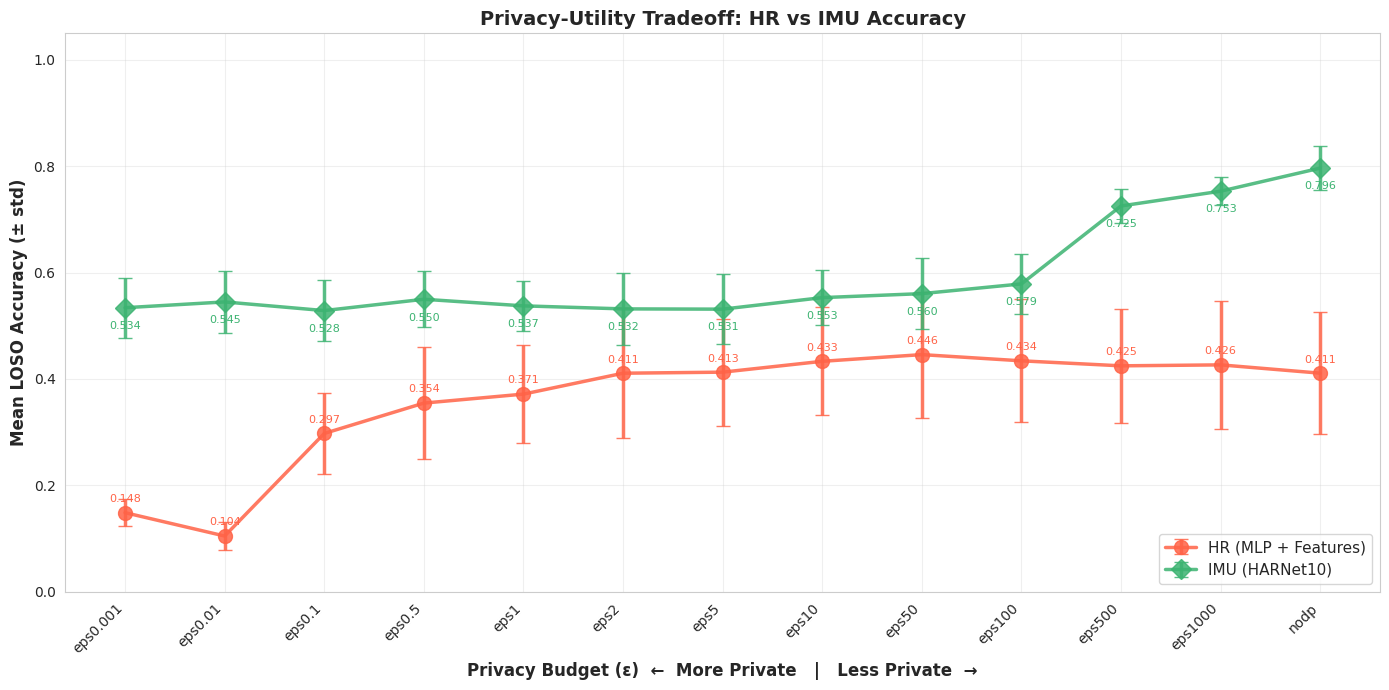

In [ ]:
# ============================================================================
# CELL 5: Privacy-Utility Tradeoff Plot (Accuracy)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data ordered by epsilon
epsilon_labels = []
hr_acc_means = []
hr_acc_stds = []
imu_acc_means = []
imu_acc_stds = []

for eps_str in EPSILON_STRINGS:
    subset = summary_stats[summary_stats['epsilon'] == eps_str]
    if len(subset) > 0:
        epsilon_labels.append(eps_str)
        hr_acc_means.append(subset['hr_acc_mean'].values[0])
        hr_acc_stds.append(subset['hr_acc_std'].values[0])
        imu_acc_means.append(subset['imu_acc_mean'].values[0])
        imu_acc_stds.append(subset['imu_acc_std'].values[0])

x = np.arange(len(epsilon_labels))

# Plot with error bars
ax.errorbar(x, hr_acc_means, yerr=hr_acc_stds,
            marker='o', markersize=10, linewidth=2.5, capsize=5,
            label='HR (MLP + Features)', color='tomato', alpha=0.85)

ax.errorbar(x, imu_acc_means, yerr=imu_acc_stds,
            marker='D', markersize=10, linewidth=2.5, capsize=5,
            label='IMU (HARNet10)', color='mediumseagreen', alpha=0.85)

# Add value labels
for i, (hr_val, imu_val) in enumerate(zip(hr_acc_means, imu_acc_means)):
    ax.text(i, hr_val + 0.02, f'{hr_val:.3f}', ha='center', fontsize=8, color='tomato')
    ax.text(i, imu_val - 0.04, f'{imu_val:.3f}', ha='center', fontsize=8, color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(epsilon_labels, rotation=45, ha='right')
ax.set_xlabel('Privacy Budget (ε)  ←  More Private   |   Less Private  →', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean LOSO Accuracy (± std)', fontsize=12, fontweight='bold')
ax.set_title('Privacy-Utility Tradeoff: HR vs IMU Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('privacy_utility_accuracy.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: privacy_utility_accuracy.png")
plt.show()


✓ Saved: privacy_utility_f1.png


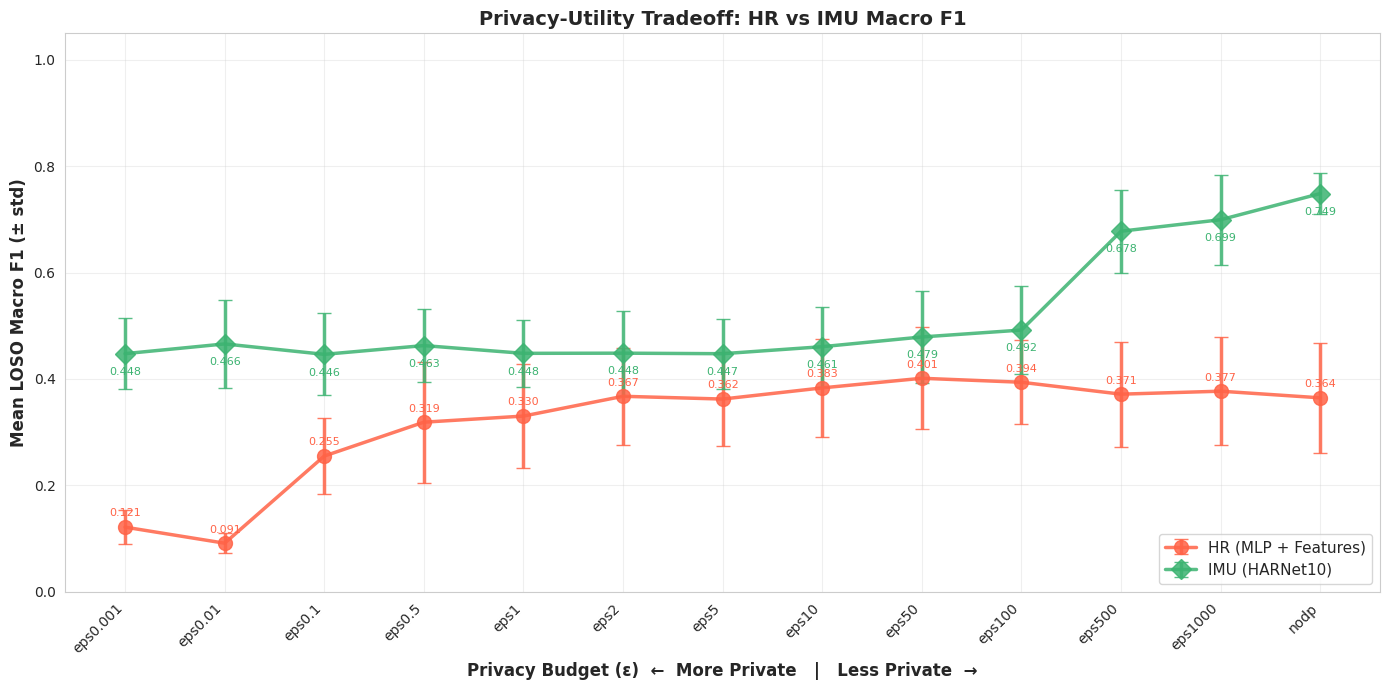

In [ ]:
# ============================================================================
# CELL 6: Privacy-Utility Tradeoff Plot (Macro F1)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data
hr_f1_means = []
hr_f1_stds = []
imu_f1_means = []
imu_f1_stds = []

for eps_str in EPSILON_STRINGS:
    subset = summary_stats[summary_stats['epsilon'] == eps_str]
    if len(subset) > 0:
        hr_f1_means.append(subset['hr_f1_mean'].values[0])
        hr_f1_stds.append(subset['hr_f1_std'].values[0])
        imu_f1_means.append(subset['imu_f1_mean'].values[0])
        imu_f1_stds.append(subset['imu_f1_std'].values[0])

x = np.arange(len(epsilon_labels))

# Plot with error bars
ax.errorbar(x, hr_f1_means, yerr=hr_f1_stds,
            marker='o', markersize=10, linewidth=2.5, capsize=5,
            label='HR (MLP + Features)', color='tomato', alpha=0.85)

ax.errorbar(x, imu_f1_means, yerr=imu_f1_stds,
            marker='D', markersize=10, linewidth=2.5, capsize=5,
            label='IMU (HARNet10)', color='mediumseagreen', alpha=0.85)

# Add value labels
for i, (hr_val, imu_val) in enumerate(zip(hr_f1_means, imu_f1_means)):
    ax.text(i, hr_val + 0.02, f'{hr_val:.3f}', ha='center', fontsize=8, color='tomato')
    ax.text(i, imu_val - 0.04, f'{imu_val:.3f}', ha='center', fontsize=8, color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(epsilon_labels, rotation=45, ha='right')
ax.set_xlabel('Privacy Budget (ε)  ←  More Private   |   Less Private  →', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean LOSO Macro F1 (± std)', fontsize=12, fontweight='bold')
ax.set_title('Privacy-Utility Tradeoff: HR vs IMU Macro F1', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('privacy_utility_f1.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: privacy_utility_f1.png")
plt.show()


✓ Saved: per_subject_accuracy_comparison.png


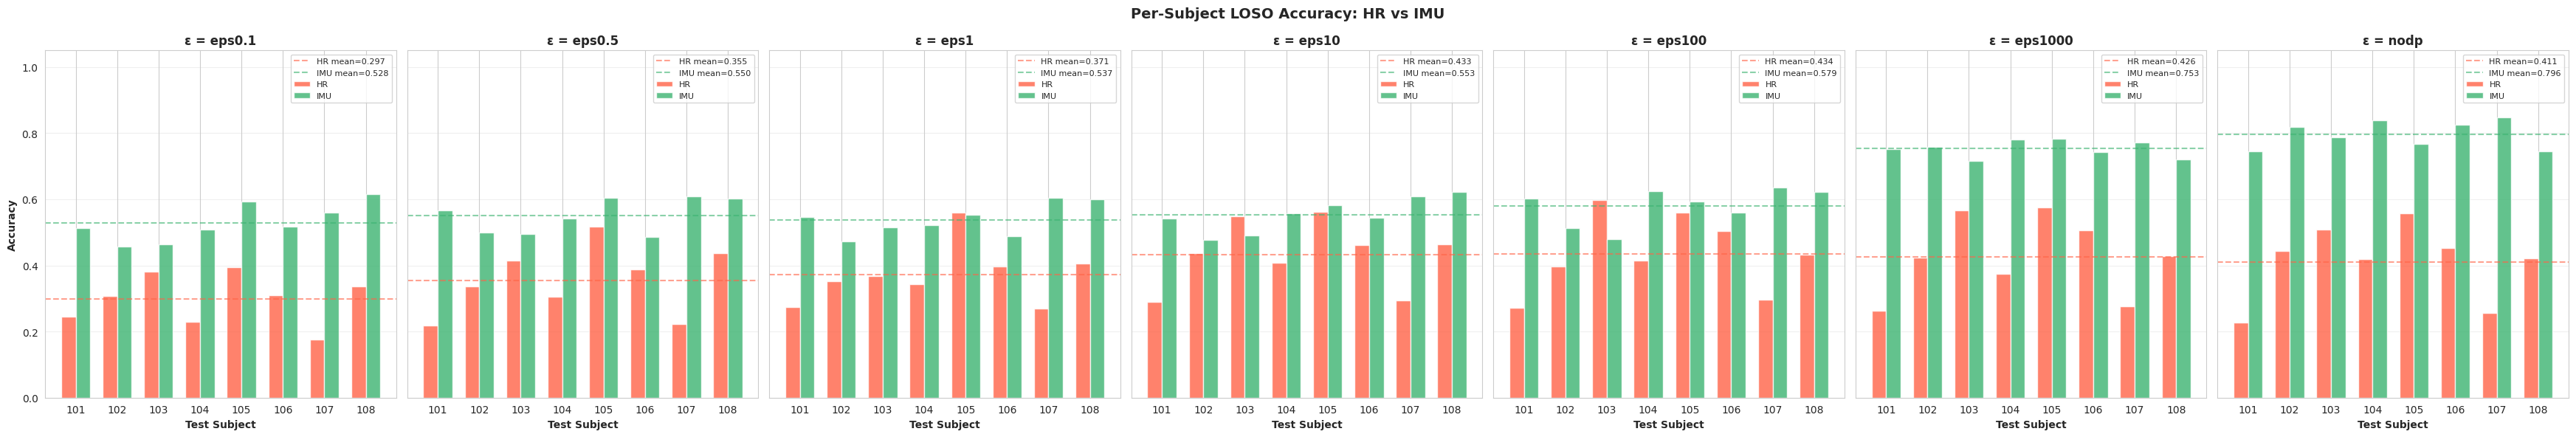

In [ ]:
# ============================================================================
# CELL 7: Per-Subject Comparison (Accuracy)
# ============================================================================

# Select key epsilon values for clearer visualization
key_epsilons = ['eps0.1', 'eps0.5', 'eps1', 'eps10', 'eps100', 'eps1000', 'nodp']
available_key_eps = [e for e in key_epsilons if e in EPSILON_STRINGS]

n_eps = len(available_key_eps)
fig, axes = plt.subplots(1, n_eps, figsize=(5*n_eps, 6), sharey=True)

if n_eps == 1:
    axes = [axes]

for ax, eps_str in zip(axes, available_key_eps):
    subset = results_df[results_df['epsilon'] == eps_str].sort_values('subject')

    x = np.arange(len(subset))
    width = 0.35

    ax.bar(x - width/2, subset['hr_acc'], width,
           label='HR', color='tomato', alpha=0.8)
    ax.bar(x + width/2, subset['imu_acc'], width,
           label='IMU', color='mediumseagreen', alpha=0.8)

    # Add mean lines
    ax.axhline(subset['hr_acc'].mean(), color='tomato',
               linestyle='--', linewidth=1.5, alpha=0.6,
               label=f'HR mean={subset["hr_acc"].mean():.3f}')
    ax.axhline(subset['imu_acc'].mean(), color='mediumseagreen',
               linestyle='--', linewidth=1.5, alpha=0.6,
               label=f'IMU mean={subset["imu_acc"].mean():.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels(subset['subject'])
    ax.set_xlabel('Test Subject', fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title(f'ε = {eps_str}', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Subject LOSO Accuracy: HR vs IMU', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_subject_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: per_subject_accuracy_comparison.png")
plt.show()

## **FUSION SETUP**

In [ ]:
# ============================================================================
# CELL 1: Imports and Setup for Fusion Experiments
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuration
SUBJECT_IDS = [101, 102, 103, 104, 105, 106, 107, 108]
NUM_CLASSES = 18
EPSILON_VALUES_ALL = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, None]

def epsilon_to_str(eps):
    """Convert epsilon value to filename string"""
    if eps is None:
        return "nodp"
    else:
        return f"eps{eps}"

EPSILON_STRINGS = [epsilon_to_str(e) for e in EPSILON_VALUES_ALL]

print("="*80)
print("FUSION EXPERIMENTS SETUP")
print("="*80)
print(f"Subjects: {SUBJECT_IDS}")
print(f"Epsilon values: {len(EPSILON_STRINGS)}")
print(f"Classes: {NUM_CLASSES}")

FUSION EXPERIMENTS SETUP
Subjects: [101, 102, 103, 104, 105, 106, 107, 108]
Epsilon values: 13
Classes: 18


In [ ]:
# ============================================================================
# CELL 2: Fusion Strategy Functions
# ============================================================================

def weighted_average_fusion(hr_probs, imu_probs, hr_weight=0.3):
    """Simple weighted average: hr_weight * HR + (1-hr_weight) * IMU"""
    return hr_weight * hr_probs + (1 - hr_weight) * imu_probs


def max_confidence_fusion(hr_probs, imu_probs):
    """Choose the prediction with highest confidence from either modality"""
    hr_max = hr_probs.max(axis=1, keepdims=True)
    imu_max = imu_probs.max(axis=1, keepdims=True)
    use_hr = (hr_max >= imu_max).squeeze()

    result = np.zeros_like(hr_probs)
    result[use_hr] = hr_probs[use_hr]
    result[~use_hr] = imu_probs[~use_hr]
    return result


def product_fusion(hr_probs, imu_probs):
    """Product rule: multiply probabilities (renormalize)"""
    product = hr_probs * imu_probs
    return product / product.sum(axis=1, keepdims=True)


def build_fusion_mlp(input_dim, num_classes, architecture="default"):
    """Build fusion MLP with different architectures"""
    if architecture == "default":
        model = Sequential([
            Dense(64, activation='relu', input_shape=(input_dim,)),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(num_classes, activation='softmax')
        ])
    elif architecture == "deep":
        model = Sequential([
            Dense(128, activation='relu', input_shape=(input_dim,)),
            BatchNormalization(), Dropout(0.4),
            Dense(64, activation='relu'),
            BatchNormalization(), Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(num_classes, activation='softmax')
        ])
    elif architecture == "shallow":
        model = Sequential([
            Dense(32, activation='relu', input_shape=(input_dim,)),
            Dropout(0.2),
            Dense(num_classes, activation='softmax')
        ])
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("✓ Fusion strategies defined:")
print("  - Weighted Average")
print("  - Max Confidence")
print("  - Product Rule")
print("  - MLP (shallow/default/deep)")

✓ Fusion strategies defined:
  - Weighted Average
  - Max Confidence
  - Product Rule
  - MLP (shallow/default/deep)


In [ ]:
# ============================================================================
# CELL 3: Load Probabilities Function
# ============================================================================

def load_probs(test_sid, epsilon_str):
    """Load HR and IMU probabilities for a given fold and epsilon"""

    # Load test probs (FILES IN CURRENT DIRECTORY)
    hr_test_path = f"hr_test_sub{test_sid}_{epsilon_str}.csv"
    imu_test_path = f"imu_test_sub{test_sid}_{epsilon_str}.csv"

    if not os.path.exists(hr_test_path) or not os.path.exists(imu_test_path):
        raise FileNotFoundError(f"Missing probs for test_sid={test_sid}, epsilon={epsilon_str}")

    hr_test_df = pd.read_csv(hr_test_path)
    imu_test_df = pd.read_csv(imu_test_path)

    hr_test_probs = hr_test_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
    imu_test_probs = imu_test_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
    y_test = imu_test_df["y_true"].values  # Use IMU labels as ground truth

    # Load train probs for all other subjects
    train_sids = [s for s in SUBJECT_IDS if s != test_sid]
    hr_train_list, imu_train_list, y_train_list = [], [], []

    for sid in train_sids:
        hr_train_path = f"hr_train_sub{sid}_fold{test_sid}_{epsilon_str}.csv"
        imu_train_path = f"imu_train_sub{sid}_fold{test_sid}_{epsilon_str}.csv"

        if not os.path.exists(hr_train_path) or not os.path.exists(imu_train_path):
            print(f"  Warning: Missing train probs for subject {sid}, skipping...")
            continue

        hr_train_df = pd.read_csv(hr_train_path)
        imu_train_df = pd.read_csv(imu_train_path)

        hr_p = hr_train_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
        imu_p = imu_train_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
        y = imu_train_df["y_true"].values

        # Align lengths (use minimum)
        n = min(len(hr_p), len(imu_p))
        hr_train_list.append(hr_p[:n])
        imu_train_list.append(imu_p[:n])
        y_train_list.append(y[:n])

    hr_train_probs = np.concatenate(hr_train_list)
    imu_train_probs = np.concatenate(imu_train_list)
    y_train = np.concatenate(y_train_list)

    # Align test lengths
    n_test = min(len(hr_test_probs), len(imu_test_probs))
    hr_test_probs = hr_test_probs[:n_test]
    imu_test_probs = imu_test_probs[:n_test]
    y_test = y_test[:n_test]

    return {
        "hr_train": hr_train_probs,
        "imu_train": imu_train_probs,
        "y_train": y_train,
        "hr_test": hr_test_probs,
        "imu_test": imu_test_probs,
        "y_test": y_test,
    }

print("✓ Data loading function defined")

✓ Data loading function defined


In [ ]:
# ============================================================================
# CELL 4: Run Single Fusion Experiment
# ============================================================================

def run_fusion_experiment(test_sid, epsilon_str, fusion_strategy="mlp", **kwargs):
    """
    Run a fusion experiment for a single fold.

    Args:
        test_sid: Test subject ID
        epsilon_str: Epsilon string (e.g., "nodp", "eps0.5")
        fusion_strategy: "mlp", "weighted_avg", "max_conf", or "product"
        **kwargs: Additional arguments (e.g., hr_weight, architecture)
    """

    # Load probabilities
    data = load_probs(test_sid, epsilon_str)

    if fusion_strategy == "mlp":
        architecture = kwargs.get("architecture", "default")
        epochs = kwargs.get("epochs", 50)
        batch_size = kwargs.get("batch_size", 32)

        # Concatenate HR and IMU probs
        X_train = np.concatenate([data["hr_train"], data["imu_train"]], axis=1)
        X_test = np.concatenate([data["hr_test"], data["imu_test"]], axis=1)

        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train MLP
        model = build_fusion_mlp(X_train.shape[1], NUM_CLASSES, architecture)
        model.fit(X_train, to_categorical(data["y_train"], NUM_CLASSES),
                  epochs=epochs, batch_size=batch_size, verbose=0)

        # Predict
        y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

    elif fusion_strategy == "weighted_avg":
        hr_weight = kwargs.get("hr_weight", 0.3)
        fused_probs = weighted_average_fusion(data["hr_test"], data["imu_test"], hr_weight)
        y_pred = fused_probs.argmax(axis=1)

    elif fusion_strategy == "max_conf":
        fused_probs = max_confidence_fusion(data["hr_test"], data["imu_test"])
        y_pred = fused_probs.argmax(axis=1)

    elif fusion_strategy == "product":
        fused_probs = product_fusion(data["hr_test"], data["imu_test"])
        y_pred = fused_probs.argmax(axis=1)

    else:
        raise ValueError(f"Unknown fusion strategy: {fusion_strategy}")

    # Evaluate
    acc = accuracy_score(data["y_test"], y_pred)
    f1 = f1_score(data["y_test"], y_pred, average="macro", zero_division=0)

    return {
        "accuracy": acc,
        "f1": f1,
        "y_true": data["y_test"],
        "y_pred": y_pred,
    }

print("✓ Fusion experiment runner defined")

✓ Fusion experiment runner defined


## **FUSION STRATEGY SELECTION - SUBJECT 105**

In [ ]:
# ============================================================================
# CELL 5 (SINGLE SUBJECT TEST): Compare Fusion Strategies on Subject 105
# ============================================================================

from sklearn.model_selection import KFold

print("\n" + "=" * 80)
print("EXPERIMENT: Testing Fusion Strategies on Subject 105 Only")
print("=" * 80)
print("\nNote: MLP will be trained using 5-fold CV on test probabilities.\n")

# Test on subject 105 only
TEST_SUBJECT = 105

# All fusion strategies including MLP
strategies = [
    ("MLP (default)", "mlp", {"architecture": "default"}),
    ("MLP (deep)", "mlp", {"architecture": "deep"}),
    ("MLP (shallow)", "mlp", {"architecture": "shallow"}),
    ("Weighted Avg (0.1)", "weighted_avg", {"hr_weight": 0.1}),
    ("Weighted Avg (0.2)", "weighted_avg", {"hr_weight": 0.2}),
    ("Weighted Avg (0.3)", "weighted_avg", {"hr_weight": 0.3}),
    ("Weighted Avg (0.4)", "weighted_avg", {"hr_weight": 0.4}),
    ("Weighted Avg (0.5)", "weighted_avg", {"hr_weight": 0.5}),
    ("Weighted Avg (0.6)", "weighted_avg", {"hr_weight": 0.6}),
    ("Weighted Avg (0.7)", "weighted_avg", {"hr_weight": 0.7}),
    ("Weighted Avg (0.8)", "weighted_avg", {"hr_weight": 0.8}),
    ("Weighted Avg (0.9)", "weighted_avg", {"hr_weight": 0.9}),
    ("Max Confidence", "max_conf", {}),
    ("Product Rule", "product", {}),
]

def train_and_evaluate_mlp_cv(hr_probs, imu_probs, y_true, architecture="default", n_splits=5):
    """Train MLP using k-fold cross-validation on test data"""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Concatenate HR and IMU probs
    X = np.concatenate([hr_probs, imu_probs], axis=1)

    accs = []
    f1s = []

    for train_idx, val_idx in kfold.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_true[train_idx], y_true[val_idx]

        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Train MLP
        model = build_fusion_mlp(X_train_scaled.shape[1], NUM_CLASSES, architecture)
        model.fit(X_train_scaled, to_categorical(y_train, NUM_CLASSES),
                  epochs=50, batch_size=32, verbose=0)

        # Predict
        y_pred = model.predict(X_val_scaled, verbose=0).argmax(axis=1)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        accs.append(acc)
        f1s.append(f1)

    return np.mean(accs), np.mean(f1s)


fusion_results = []

for epsilon_str in EPSILON_STRINGS:
    print(f"\n{'='*70}")
    print(f"Processing epsilon: {epsilon_str}")
    print(f"{'='*70}")

    # Check if files exist
    hr_test_path = f"hr_test_sub{TEST_SUBJECT}_{epsilon_str}.csv"
    imu_test_path = f"imu_test_sub{TEST_SUBJECT}_{epsilon_str}.csv"

    if not os.path.exists(hr_test_path) or not os.path.exists(imu_test_path):
        print(f"  ⚠️ Files not found for epsilon {epsilon_str}, skipping...")
        continue

    # Load test data once for this epsilon
    hr_df = pd.read_csv(hr_test_path)
    imu_df = pd.read_csv(imu_test_path)

    hr_probs = hr_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
    imu_probs = imu_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
    y_true = imu_df["y_true"].values

    # Align lengths
    n = min(len(hr_probs), len(imu_probs))
    hr_probs = hr_probs[:n]
    imu_probs = imu_probs[:n]
    y_true = y_true[:n]

    print(f"  Data loaded: {len(y_true)} samples\n")

    for strategy_name, strategy_type, kwargs in strategies:
        try:
            # Apply fusion strategy
            if strategy_type == "mlp":
                # Use cross-validation on test data
                architecture = kwargs.get("architecture", "default")
                print(f"  Training {strategy_name}...", end=" ")
                acc, f1 = train_and_evaluate_mlp_cv(hr_probs, imu_probs, y_true, architecture)
                print(f"✓ Done")

            elif strategy_type == "weighted_avg":
                fused_probs = weighted_average_fusion(hr_probs, imu_probs,
                                                     kwargs.get("hr_weight", 0.3))
                y_pred = fused_probs.argmax(axis=1)
                acc = accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

            elif strategy_type == "max_conf":
                fused_probs = max_confidence_fusion(hr_probs, imu_probs)
                y_pred = fused_probs.argmax(axis=1)
                acc = accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

            elif strategy_type == "product":
                fused_probs = product_fusion(hr_probs, imu_probs)
                y_pred = fused_probs.argmax(axis=1)
                acc = accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

            fusion_results.append({
                "epsilon": epsilon_str,
                "strategy": strategy_name,
                "accuracy": acc,
                "f1": f1
            })

            print(f"    {strategy_name:25s}: acc={acc:.4f}  f1={f1:.4f}")

        except Exception as e:
            print(f"    ❌ {strategy_name:25s}: Error - {e}")
            continue

# Create DataFrame
fusion_df = pd.DataFrame(fusion_results)

if len(fusion_df) > 0:
    # Save results
    fusion_df.to_csv("fusion_strategy_test_subject105.csv", index=False)
    print("\n✓ Saved: fusion_strategy_test_subject105.csv")

    # Display summary
    print("\n" + "="*80)
    print("FUSION RESULTS SUMMARY - Subject 105")
    print("="*80)
    print(fusion_df.to_string(index=False))

    # Show best strategy per epsilon
    print("\n" + "="*80)
    print("BEST STRATEGY PER EPSILON (Subject 105)")
    print("="*80)
    for eps_str in fusion_df['epsilon'].unique():
        subset = fusion_df[fusion_df['epsilon'] == eps_str]
        best = subset.loc[subset['accuracy'].idxmax()]
        print(f"\n{eps_str:15s}: {best['strategy']:25s}")
        print(f"                 → Accuracy: {best['accuracy']:.4f}  |  F1: {best['f1']:.4f}")

    # Overall best strategy (averaged across all epsilons)
    print("\n" + "="*80)
    print("OVERALL BEST STRATEGY (Averaged Across All Epsilons)")
    print("="*80)
    avg_perf = fusion_df.groupby('strategy').agg({
        'accuracy': ['mean', 'std'],
        'f1': ['mean', 'std']
    }).round(4)
    avg_perf.columns = ['_'.join(col).strip() for col in avg_perf.columns.values]
    avg_perf = avg_perf.sort_values('accuracy_mean', ascending=False)
    print(avg_perf.to_string())

    print("\n🏆 WINNER:")
    best_overall = avg_perf.iloc[0]
    print(f"   {avg_perf.index[0]}")
    print(f"   → Mean Accuracy: {best_overall['accuracy_mean']:.4f} ± {best_overall['accuracy_std']:.4f}")
    print(f"   → Mean F1:       {best_overall['f1_mean']:.4f} ± {best_overall['f1_std']:.4f}")

else:
    print("\n❌ No fusion results generated. Check if test files exist for subject 105.")


EXPERIMENT: Testing Fusion Strategies on Subject 105 Only

Note: MLP will be trained using 5-fold CV on test probabilities.


Processing epsilon: eps0.001
  Data loaded: 544 samples

  Training MLP (default)... ✓ Done
    MLP (default)            : acc=0.6857  f1=0.6346
  Training MLP (deep)... ✓ Done
    MLP (deep)               : acc=0.7022  f1=0.6493
  Training MLP (shallow)... ✓ Done
    MLP (shallow)            : acc=0.7003  f1=0.6579
    Weighted Avg (0.1)       : acc=0.5625  f1=0.5228
    Weighted Avg (0.2)       : acc=0.5662  f1=0.5277
    Weighted Avg (0.3)       : acc=0.5680  f1=0.5339
    Weighted Avg (0.4)       : acc=0.5680  f1=0.5321
    Weighted Avg (0.5)       : acc=0.5625  f1=0.5261
    Weighted Avg (0.6)       : acc=0.5680  f1=0.5259
    Weighted Avg (0.7)       : acc=0.5699  f1=0.5267
    Weighted Avg (0.8)       : acc=0.5368  f1=0.4951
    Weighted Avg (0.9)       : acc=0.4393  f1=0.4069
    Max Confidence           : acc=0.5607  f1=0.5232
    Product Rule         

## **FUSION EXPERIMENTS - ALL EPSILONS**

In [ ]:
# ============================================================================
# EXPERIMENT 1: Deep MLP Fusion with SAME Epsilon (All Subjects)
# ============================================================================

from sklearn.model_selection import KFold

print("\n" + "=" * 80)
print("EXPERIMENT 1: Deep MLP Fusion with SAME Epsilon")
print("=" * 80)
print("Testing all subjects with matching HR and IMU epsilon values\n")

def train_and_evaluate_mlp_cv(hr_probs, imu_probs, y_true, architecture="deep", n_splits=5):
    """Train MLP using k-fold cross-validation on test data"""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Concatenate HR and IMU probs
    X = np.concatenate([hr_probs, imu_probs], axis=1)

    accs = []
    f1s = []

    for train_idx, val_idx in kfold.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_true[train_idx], y_true[val_idx]

        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Train Deep MLP
        model = build_fusion_mlp(X_train_scaled.shape[1], NUM_CLASSES, architecture)
        model.fit(X_train_scaled, to_categorical(y_train, NUM_CLASSES),
                  epochs=50, batch_size=32, verbose=0)

        # Predict
        y_pred = model.predict(X_val_scaled, verbose=0).argmax(axis=1)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        accs.append(acc)
        f1s.append(f1)

    return np.mean(accs), np.mean(f1s)


same_epsilon_results = []

for epsilon_str in EPSILON_STRINGS:
    print(f"\nProcessing epsilon: {epsilon_str}")

    for test_sid in SUBJECT_IDS:
        # Load test files with SAME epsilon
        hr_test_path = f"hr_test_sub{test_sid}_{epsilon_str}.csv"
        imu_test_path = f"imu_test_sub{test_sid}_{epsilon_str}.csv"

        if not os.path.exists(hr_test_path) or not os.path.exists(imu_test_path):
            continue

        try:
            # Load test data
            hr_df = pd.read_csv(hr_test_path)
            imu_df = pd.read_csv(imu_test_path)

            hr_probs = hr_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
            imu_probs = imu_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
            y_true = imu_df["y_true"].values

            # Align lengths
            n = min(len(hr_probs), len(imu_probs))
            hr_probs = hr_probs[:n]
            imu_probs = imu_probs[:n]
            y_true = y_true[:n]

            # Train and evaluate
            acc, f1 = train_and_evaluate_mlp_cv(hr_probs, imu_probs, y_true)

            same_epsilon_results.append({
                "subject": test_sid,
                "epsilon": epsilon_str,
                "hr_epsilon": epsilon_str,
                "imu_epsilon": epsilon_str,
                "accuracy": acc,
                "f1": f1
            })

            print(f"  Subject {test_sid}: acc={acc:.4f}  f1={f1:.4f}")

        except Exception as e:
            print(f"  ❌ Subject {test_sid}: Error - {e}")
            continue

# Create DataFrame
same_eps_df = pd.DataFrame(same_epsilon_results)

if len(same_eps_df) > 0:
    # Save results
    same_eps_df.to_csv("fusion_deep_mlp_same_epsilon.csv", index=False)
    print("\n✓ Saved: fusion_deep_mlp_same_epsilon.csv")

    # Summary statistics
    summary = same_eps_df.groupby('epsilon').agg({
        'accuracy': ['mean', 'std', 'count'],
        'f1': ['mean', 'std']
    }).round(4)
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]

    print("\n" + "="*80)
    print("SAME EPSILON FUSION SUMMARY")
    print("="*80)
    print(summary.to_string())

else:
    print("\n❌ No results generated.")

KeyboardInterrupt: 

This experiment takes several hours to complete. The execution shown above was manually interrupted after the required outputs had already been generated.

In [ ]:
# ============================================================================
# EXPERIMENT 2: Deep MLP Fusion with MIXED Epsilon (Privacy-Matched)
# ============================================================================

print("\n" + "=" * 80)
print("EXPERIMENT 2: Deep MLP Fusion with MIXED Epsilon")
print("=" * 80)
print("Matching HR and IMU based on similar privacy-utility tradeoff\n")

# Define epsilon pairs based on your plot analysis
# (hr_epsilon, imu_epsilon, description)
epsilon_pairs = [
    ("eps1", "eps1000", "HR ε=1 ≈ IMU ε=1000"),
    ("eps0.5", "eps500", "HR ε=0.5 ≈ IMU ε=500"),
    ("eps0.1", "eps100", "HR ε=0.1 ≈ IMU ε=100"),
    ("eps0.01", "eps50", "HR ε=0.01 ≈ IMU ε=50"),
]

mixed_epsilon_results = []

for hr_eps, imu_eps, description in epsilon_pairs:
    print(f"\n{description}")
    print(f"  HR ε={hr_eps} + IMU ε={imu_eps}")

    for test_sid in SUBJECT_IDS:
        # Load test files with DIFFERENT epsilons
        hr_test_path = f"hr_test_sub{test_sid}_{hr_eps}.csv"
        imu_test_path = f"imu_test_sub{test_sid}_{imu_eps}.csv"

        if not os.path.exists(hr_test_path) or not os.path.exists(imu_test_path):
            print(f"  ⚠️ Subject {test_sid}: Files not found, skipping...")
            continue

        try:
            # Load test data
            hr_df = pd.read_csv(hr_test_path)
            imu_df = pd.read_csv(imu_test_path)

            hr_probs = hr_df[[f"hr_p{i}" for i in range(NUM_CLASSES)]].values
            imu_probs = imu_df[[f"imu_p{i}" for i in range(NUM_CLASSES)]].values
            y_true = imu_df["y_true"].values

            # Align lengths
            n = min(len(hr_probs), len(imu_probs))
            hr_probs = hr_probs[:n]
            imu_probs = imu_probs[:n]
            y_true = y_true[:n]

            # Train and evaluate
            acc, f1 = train_and_evaluate_mlp_cv(hr_probs, imu_probs, y_true)

            mixed_epsilon_results.append({
                "subject": test_sid,
                "pair_name": f"{hr_eps}+{imu_eps}",
                "hr_epsilon": hr_eps,
                "imu_epsilon": imu_eps,
                "description": description,
                "accuracy": acc,
                "f1": f1
            })

            print(f"  Subject {test_sid}: acc={acc:.4f}  f1={f1:.4f}")

        except Exception as e:
            print(f"  ❌ Subject {test_sid}: Error - {e}")
            continue

# Create DataFrame
mixed_eps_df = pd.DataFrame(mixed_epsilon_results)

if len(mixed_eps_df) > 0:
    # Save results
    mixed_eps_df.to_csv("fusion_deep_mlp_mixed_epsilon.csv", index=False)
    print("\n✓ Saved: fusion_deep_mlp_mixed_epsilon.csv")

    # Summary statistics
    summary = mixed_eps_df.groupby('pair_name').agg({
        'accuracy': ['mean', 'std', 'count'],
        'f1': ['mean', 'std']
    }).round(4)
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]

    print("\n" + "="*80)
    print("MIXED EPSILON FUSION SUMMARY")
    print("="*80)
    print(summary.to_string())

    # Also show with descriptions
    print("\n" + "="*80)
    print("MIXED EPSILON PAIRS - DETAILED RESULTS")
    print("="*80)
    for pair_name in mixed_eps_df['pair_name'].unique():
        subset = mixed_eps_df[mixed_eps_df['pair_name'] == pair_name]
        print(f"\n{subset.iloc[0]['description']}")
        print(f"  Mean Accuracy: {subset['accuracy'].mean():.4f} ± {subset['accuracy'].std():.4f}")
        print(f"  Mean F1:       {subset['f1'].mean():.4f} ± {subset['f1'].std():.4f}")

else:
    print("\n❌ No results generated.")


EXPERIMENT 2: Deep MLP Fusion with MIXED Epsilon
Matching HR and IMU based on similar privacy-utility tradeoff


HR ε=1 ≈ IMU ε=1000
  HR ε=eps1 + IMU ε=eps1000
  Subject 101: acc=0.8480  f1=0.8476
  Subject 102: acc=0.8749  f1=0.8685
  Subject 103: acc=0.8475  f1=0.8240
  Subject 104: acc=0.8750  f1=0.8645
  Subject 105: acc=0.8879  f1=0.8907
  Subject 106: acc=0.8796  f1=0.8746
  Subject 107: acc=0.8706  f1=0.8353
  Subject 108: acc=0.8661  f1=0.8380

HR ε=0.5 ≈ IMU ε=500
  HR ε=eps0.5 + IMU ε=eps500
  Subject 101: acc=0.8700  f1=0.8555
  Subject 102: acc=0.8217  f1=0.7707
  Subject 103: acc=0.8046  f1=0.7917
  Subject 104: acc=0.8663  f1=0.8569
  Subject 105: acc=0.8475  f1=0.8468
  Subject 106: acc=0.8756  f1=0.8806
  Subject 107: acc=0.8556  f1=0.8340
  Subject 108: acc=0.8471  f1=0.8339

HR ε=0.1 ≈ IMU ε=100
  HR ε=eps0.1 + IMU ε=eps100
  Subject 101: acc=0.7420  f1=0.7135
  Subject 102: acc=0.7571  f1=0.7126
  Subject 103: acc=0.7182  f1=0.6619
  Subject 104: acc=0.7414  f1=0.7